## Preprocessing

In [1]:
# Importing the dataset
import pandas as pd

df = pd.read_csv("../data/working.csv")

In [2]:
# checking for missing values
print(df.isnull().values.any())
print(df.isnull().sum().sum())

False
0


In [3]:
# selcting only needed features from the dataset
selected_features = [
    "URLLength",
    "IsDomainIP",
    "TLD",
    "NoOfDegitsInURL",
    "NoOfOtherSpecialCharsInURL",
    "IsHTTPS",
    "DomainLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "label"
]

df = df[selected_features]

In [4]:
# seperate the solution (if phishing or legitimate url) from the rest of the data
X = df.drop("label", axis=1)
y = df["label"]

In [5]:
print(df.columns)
print(X.columns)
print(y.name)

Index(['URLLength', 'IsDomainIP', 'TLD', 'NoOfDegitsInURL',
       'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'DomainLength',
       'NoOfSubDomain', 'HasObfuscation', 'label'],
      dtype='object')
Index(['URLLength', 'IsDomainIP', 'TLD', 'NoOfDegitsInURL',
       'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'DomainLength',
       'NoOfSubDomain', 'HasObfuscation'],
      dtype='object')
label


In [6]:
# Checking how many different tld's there are
df["TLD"].nunique()

695

In [7]:
# looking at the top 10 most prevalant
top_tlds = X["TLD"].value_counts().nlargest(10).index
print(top_tlds.values)
X["TLD"].value_counts()

['com' 'org' 'net' 'app' 'uk' 'co' 'io' 'de' 'ru' 'au']


TLD
com           112554
org            18793
net             7097
app             6508
uk              6395
               ...  
15                 1
nr                 1
parts              1
kitchen            1
associates         1
Name: count, Length: 695, dtype: int64

In [8]:
# replacing every other tld with other to limit the amount of different values to 11:
X["TLD"] = X["TLD"].apply(lambda x: x if x in top_tlds else "other")
X["TLD"].nunique()

11

In [9]:
# creating new features to encode the TLD feature into 1 and 0 values for each common top level domain:
X = pd.get_dummies(X, columns=["TLD"])
print(X.columns)
print(len(X.columns))

Index(['URLLength', 'IsDomainIP', 'NoOfDegitsInURL',
       'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'DomainLength',
       'NoOfSubDomain', 'HasObfuscation', 'TLD_app', 'TLD_au', 'TLD_co',
       'TLD_com', 'TLD_de', 'TLD_io', 'TLD_net', 'TLD_org', 'TLD_other',
       'TLD_ru', 'TLD_uk'],
      dtype='object')
19


## Data split

In [10]:
# splitting data into training and testing sets. X is data and y is for evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(188636, 19) (47159, 19)


In [11]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# training the first model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

In [13]:
import joblib

joblib.dump(model_lr, "../models/linear_model3.pkl")

['../models/linear_model3.pkl']

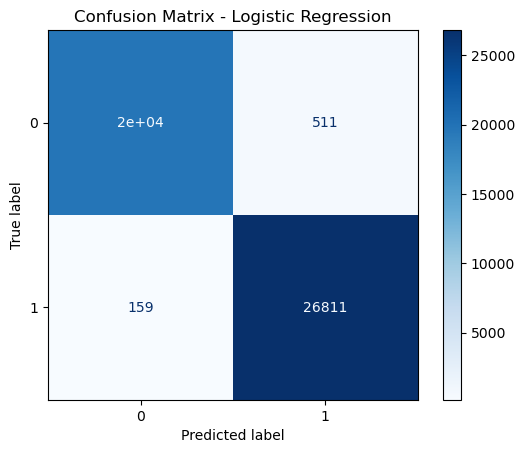

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Experimenting with the Threshold:

#### Threshold Adjustment to Reduce False Negatives

The default decision threshold of logistic regression is **0.5**, meaning a URL is classified as **phishing** (label=0) only if the predicted probability is under 50%. Since phishing URLs are label=0, lifting this threshold actually flags *more* URLs as phishing.

To reduce false negatives, the threshold was lifted to **0.8**. This makes the model more sensitive to potential phishing URLs.


In [15]:
# training the model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob >= 0.8).astype(int)

In [16]:
# evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9894611845034882
[[20043   146]
 [  351 26619]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     20189
           1       0.99      0.99      0.99     26970

    accuracy                           0.99     47159
   macro avg       0.99      0.99      0.99     47159
weighted avg       0.99      0.99      0.99     47159



#### Interpretation:

False negatives dropped significantly (511 → 146).

False positives increased (159 → 351).

Accuracy increased slightly (98.58% → 98.95%).

#### Threshold Adjustment to Reduce False Negatives

To further reduce false negatives, the threshold was lifted to **0.9**. This makes the model more sensitive to potential phishing URLs.


In [17]:
# training the model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob >= 0.9).astype(int)

In [18]:
# evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9744057337941856
[[20089   100]
 [ 1107 25863]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     20189
           1       1.00      0.96      0.98     26970

    accuracy                           0.97     47159
   macro avg       0.97      0.98      0.97     47159
weighted avg       0.98      0.97      0.97     47159



#### Interpretation:
False negatives decreased further: 146 → 100

False positives increased: 351 → 1107

Accuracy dropped slightly: 98.95% → 97.44%

#### Threshold Adjustment to Reduce False Negatives

To further reduce false negatives, the threshold was lifted to **0.95**. This makes the model more sensitive to potential phishing URLs.

In [19]:
# training the model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob >= 0.95).astype(int)

In [20]:
# evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9615343836807396
[[20097    92]
 [ 1722 25248]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     20189
           1       1.00      0.94      0.97     26970

    accuracy                           0.96     47159
   macro avg       0.96      0.97      0.96     47159
weighted avg       0.96      0.96      0.96     47159



#### Interpretation:

False negatives decreased further: 100 → 92

False positives increased: 1107 → 1722

Accuracy dropped slightly: 97.44% → 96.15%

#### Threshold Adjustment to Reduce False Negatives

To further reduce false negatives, the threshold was lifted to **0.9555**. This makes the model more sensitive to potential phishing URLs.

In [21]:
# training the model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
# decision threshold lowered to 0.0005
y_pred_lr = (y_prob >= 0.9555).astype(int)

In [22]:
# evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9610890816175067
[[20098    91]
 [ 1744 25226]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     20189
           1       1.00      0.94      0.96     26970

    accuracy                           0.96     47159
   macro avg       0.96      0.97      0.96     47159
weighted avg       0.96      0.96      0.96     47159



#### Interpretation:
**0.8**:
False negatives dropped significantly (511 → 146).

False positives increased (159 → 351).

Accuracy increased slightly (98.58% → 98.95%).

**0.9**:
False negatives decreased further: 146 → 100

False positives increased: 351 → 1107

Accuracy dropped slightly: 98.95% → 97.44%

**0.95**:
False negatives decreased further: 100 → 92

False positives increased: 1107 → 1722

Accuracy dropped slightly: 97.44% → 96.15%

**0.9555**:
False negatives decreased further: 92 → **91**

False positives increased: 1722 → 1744

Accuracy dropped slightly: 96.15% → 96.11%

In [23]:
# cross validation to ensure the result is stable
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_lr, X, y, cv=5)

print(scores.mean())

0.9966793188998917


## conclusion


In this dataset, label=0 is phishing and label=1 is legitimate. `predict_proba[:, 1]` returns the probability of label=1 (legitimate). Lifting the threshold therefore predicts phishing *more* aggressively — classifying more URLs as phishing (label=0). This does reduce false negatives (missed phishing). 

by adjusting the threshold from 0.5 to 0.9555, the **false negatives dropped from 511 to 91, but false positives increased from 159 to 1744 and accuracy dropped from 98.58% to 96.11%** 

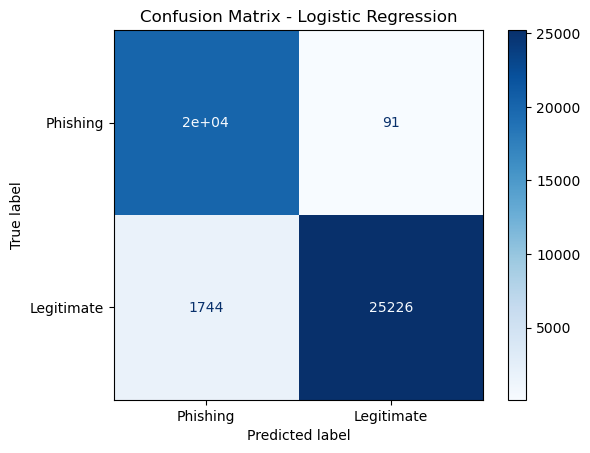

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Phishing", "Legitimate"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()